# SentinelAI — المرحلة ١: تنظيف البيانات والرسوميات (EDA)

الهدف من هذا الـ Notebook هو **فهم** بيانات `CSE-CIC-IDS2018` وتنظيفها، وعرض رسوميات
توضّح شكل البيانات، **قبل** أي تدريب لنماذج (التدريب سيكون في مرحلة لاحقة).

**خطوات هذا الملف:**
1. قراءة ملف/ملفات CSV من مجلد `data/` وتنظيف أسماء الأعمدة.
2. عرض معلومات أساسية عن البيانات (الحجم، الأنواع، القيم الناقصة).
3. تنظيف البيانات (قيم ناقصة، قيم لا نهائية، تكرارات).
4. عرض توزيع الفئات في عمود `Label`.
5. رسوميات: توزيع الفئات، مصفوفة الارتباط، توزيع أهم الخصائص.

> **ملاحظة قبل التشغيل:** ضع ملف أو ملفين (عيّنة، وليس كل الـ ١٦ جيجا) من بيانات
> `CSE-CIC-IDS2018` بصيغة CSV داخل مجلد `data/` بجانب هذا المشروع، ثم شغّل الخلايا بالترتيب.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

DATA_DIR = os.path.join("..", "data")

**ماذا فعلنا ولماذا؟**
استوردنا المكتبات التي سنحتاجها: `pandas` و `numpy` للتعامل مع الجداول والأرقام،
و `matplotlib` و `seaborn` للرسوميات. حدّدنا أيضاً مسار مجلد `data/` حيث نضع ملفات
الـ CSV، حتى لا نكرر كتابة المسار في كل خلية.

In [2]:
csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))

if not csv_files:
    raise FileNotFoundError(
        "لم يتم العثور على أي ملف CSV داخل مجلد data/.\n"
        "الرجاء وضع عيّنة من بيانات CSE-CIC-IDS2018 (ملف أو ملفين CSV) داخل مجلد data/ "
        "ثم إعادة تشغيل هذه الخلية."
    )

print(f"تم العثور على {len(csv_files)} ملف/ملفات CSV في data/:")
for f in csv_files:
    print(" -", os.path.basename(f))

df_list = [pd.read_csv(f, low_memory=False) for f in csv_files]
df = pd.concat(df_list, ignore_index=True)

print(f"\nإجمالي عدد الصفوف بعد دمج الملفات: {len(df):,}")

تم العثور على 1 ملف/ملفات CSV في data/:
 - cleaned_ids2018_sampled.csv



إجمالي عدد الصفوف بعد دمج الملفات: 1,252,846


**ماذا فعلنا ولماذا؟**
بحثنا عن كل ملفات الـ CSV الموجودة في `data/` وقرأناها ودمجناها في جدول واحد اسمه `df`.
هذا يسمح بوضع أكثر من ملف عيّنة (مثلاً يومين مختلفين من بيانات CSE-CIC-IDS2018) دون
تعديل الكود. استخدمنا `low_memory=False` لتفادي تحذيرات تخمين نوع العمود بسبب حجم الملف.

In [3]:
print("أمثلة على أسماء الأعمدة قبل التنظيف:")
print(list(df.columns[:5]))

df.columns = df.columns.str.strip()

if "Label" in df.columns:
    df["Label"] = df["Label"].astype(str).str.strip()

print("\nأمثلة على أسماء الأعمدة بعد التنظيف:")
print(list(df.columns[:5]))

أمثلة على أسماء الأعمدة قبل التنظيف:
['Unnamed: 0', 'Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts']



أمثلة على أسماء الأعمدة بعد التنظيف:
['Unnamed: 0', 'Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts']


**ماذا فعلنا ولماذا؟**
ملفات CICFlowMeter غالباً تحتوي على مسافات زائدة في أسماء الأعمدة (مثلاً `" Label"` بدل
`"Label"`)، وهذا يسبب أخطاء لاحقاً عند محاولة الوصول للعمود بالاسم. استخدمنا `str.strip()`
لإزالة المسافات من بداية ونهاية كل اسم عمود، وكذلك من قيم عمود `Label` نفسه.

In [4]:
print(f"عدد الصفوف: {df.shape[0]:,}")
print(f"عدد الأعمدة: {df.shape[1]:,}")

print("\nأنواع البيانات (عدد الأعمدة لكل نوع):")
print(df.dtypes.value_counts())

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(f"\nعدد الأعمدة التي فيها قيم ناقصة: {len(missing)}")
if len(missing) > 0:
    print(missing.head(10))

عدد الصفوف: 1,252,846
عدد الأعمدة: 79

أنواع البيانات (عدد الأعمدة لكل نوع):
int64      54
float64    24
str         1
Name: count, dtype: int64



عدد الأعمدة التي فيها قيم ناقصة: 0


**ماذا فعلنا ولماذا؟**
قبل أي تنظيف، من المهم أن نعرف حجم البيانات (عدد الصفوف والأعمدة)، وأنواعها (أرقام صحيحة،
أرقام عشرية، نصوص)، وعدد القيم الناقصة (Missing Values) في كل عمود. هذا يعطينا صورة
عامة قبل أن نقرر كيف سننظّف البيانات في الخطوة التالية.

In [5]:
rows_before = len(df)

# ١) استبدال القيم اللانهائية (Infinity) بـ NaN حتى نتعامل معها كقيم ناقصة
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

rows_with_na = df.isnull().any(axis=1).sum()
print(f"عدد الصفوف التي فيها قيمة ناقصة/لا نهائية على الأقل: {rows_with_na:,} "
      f"({rows_with_na / rows_before:.2%} من البيانات)")

# ٢) حذف هذه الصفوف (نسبتها عادة صغيرة جداً في هذا الـ Dataset)
df = df.dropna()

# ٣) إزالة الصفوف المكرّرة
duplicates = df.duplicated().sum()
df = df.drop_duplicates()

rows_after = len(df)

print(f"عدد الصفوف المكرّرة التي تم حذفها: {duplicates:,}")
print(f"\nعدد الصفوف قبل التنظيف: {rows_before:,}")
print(f"عدد الصفوف بعد التنظيف:  {rows_after:,}")

عدد الصفوف التي فيها قيمة ناقصة/لا نهائية على الأقل: 0 (0.00% من البيانات)


عدد الصفوف المكرّرة التي تم حذفها: 117,437

عدد الصفوف قبل التنظيف: 1,252,846
عدد الصفوف بعد التنظيف:  1,135,409


**ماذا فعلنا ولماذا؟**
بعض خصائص هذا الـ Dataset مثل `Flow Bytes/s` تُحسَب بالقسمة على الزمن، فإذا كانت مدة
التدفق صفراً تظهر قيمة **لا نهائية (Infinity)**. حوّلنا هذه القيم إلى `NaN` أولاً حتى
نقدر نتعامل معها بشكل موحّد، ثم حذفنا الصفوف الناقصة لأن نسبتها صغيرة جداً مقارنة بحجم
البيانات (حذفها أفضل من تعويضها بقيم قد تكون غير دقيقة). كذلك حذفنا أي صفوف مكرّرة تماماً
حتى لا يتعلّم النموذج لاحقاً من نفس البيانات مرتين.

In [6]:
label_counts = df["Label"].value_counts()
label_pct = df["Label"].value_counts(normalize=True) * 100

summary = pd.DataFrame({"العدد": label_counts, "النسبة %": label_pct.round(2)})
print(summary)

is_benign = df["Label"].str.lower().eq("benign")
print(f"\nنسبة الحركة الطبيعية (Benign): {is_benign.mean():.2%}")
print(f"نسبة حركة الهجمات (كل الأنواع مجتمعة): {(1 - is_benign.mean()):.2%}")

        العدد  النسبة %
Label                  
1      880060     77.51
4      124280     10.95
5       52051      4.58
2       35127      3.09
3       33817      2.98
6        7598      0.67
7        2028      0.18
8         301      0.03
9          91      0.01
10         46      0.00
11         10      0.00



نسبة الحركة الطبيعية (Benign): 0.00%
نسبة حركة الهجمات (كل الأنواع مجتمعة): 100.00%


**ماذا فعلنا ولماذا؟**
عرضنا عدد ونسبة كل فئة (Benign = طبيعي، والباقي أنواع هجمات) في عمود `Label`. هذا مهم
جداً لأن هذا الـ Dataset **غير متوازن**: الحركة الطبيعية عادة تشكّل نسبة كبيرة جداً
(حوالي ٨٣٪ كما ذكر الدكتور)، وهذا يجب أن نأخذه بعين الاعتبار **لاحقاً** عند تدريب
النماذج (مثلاً بأخذ عيّنة متوازنة أو استخدام أوزان للفئات) — لكن في هذه المرحلة نكتفي
بالملاحظة والعرض فقط، دون تدريب.

## توثيق: هل يوجد عمود نصي بأسماء الهجمات؟

تحققنا من كل الأعمدة الـ79 في الملف (`cleaned_ids2018_sampled.csv`) بشكل صريح: **لا يوجد أي عمود آخر بجانب `Label`** يحمل اسم الهجوم نصياً (لا عمود `Attack`، ولا نسخة نصية من `Label`). كل الأعمدة رقمية (int64 / float64)، وعمود `Label` نفسه هو أرقام صحيحة من 1 إلى 11 فقط. أي أن هذا الملف **مُرمَّز مسبقاً (Label Encoded)** قبل أن يصل إلينا، ولا يوجد legend مرفق يوضّح أي رقم يقابل أي اسم.

### الفئات المعروفة رسمياً في بيانات CSE-CIC-IDS2018 (للتوثيق فقط)

بيانات CSE-CIC-IDS2018 الأصلية (بملفاتها اليومية الرسمية) تحتوي عادة على هذه الفئات:

- Benign (طبيعي)
- Bot
- DoS attacks-GoldenEye
- DoS attacks-Slowloris
- DoS attacks-SlowHTTPTest
- DoS attacks-Hulk
- DDoS attacks-LOIC-HTTP
- DDOS attack-HOIC
- DDOS attack-LOIC-UDP
- Brute Force -Web
- Brute Force -XSS
- SQL Injection
- FTP-BruteForce
- SSH-Bruteforce
- Infilteration

**تنبيه مهم:** هذه العينة (`cleaned_ids2018_sampled.csv`) تحتوي على 11 رمزاً فقط (1 إلى 11) من أصل الفئات الخمس عشرة أعلاه — على الأرجح لأن بعض الأنواع النادرة جداً (مثل SQL Injection) لم تُدرَج عند أخذ العينة، أو دُمجت بعض الفئات المتشابهة. **لا يمكننا الجزم بأي رقم يقابل أي اسم من القائمة أعلاه** دون الرجوع لسكربت التحضير الأصلي لهذا الملف. الملاحظة شبه المؤكدة الوحيدة: الفئة رقم **1** (الأكبر بنسبة 77.51% من البيانات) هي الأقرب لتكون **Benign**، لأنها الأغلبية الساحقة وتتوافق مع ملاحظة الدكتور أن نسبة الحركة الطبيعية في هذا الـ Dataset ~83%. باقي الأرقام (2 إلى 11) تبقى فئات هجمات غير معروفة الاسم بالتحديد حالياً.


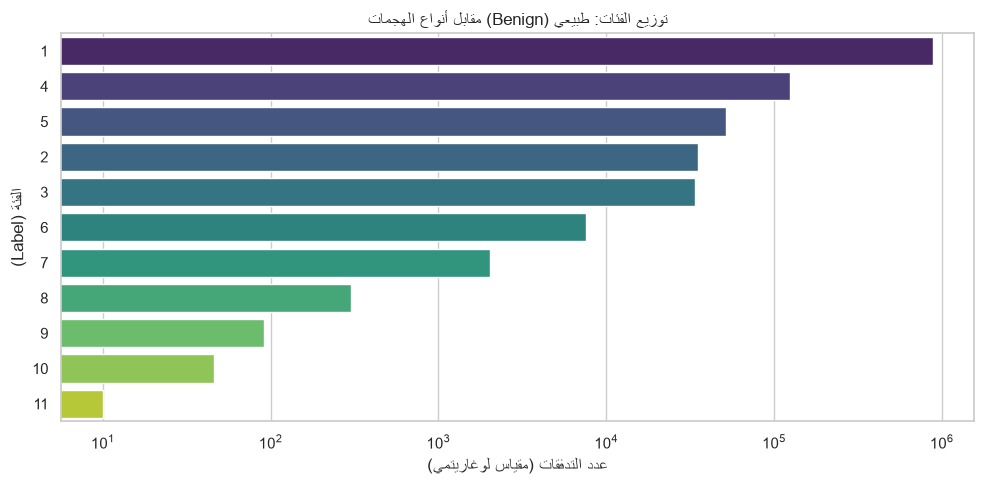

In [7]:
plt.figure(figsize=(10, 5))
order = label_counts.index
ax = sns.barplot(x=label_counts.values, y=order, hue=order, palette="viridis", legend=False)
ax.set_xscale("log")
ax.set_xlabel("عدد التدفقات (مقياس لوغاريتمي)")
ax.set_ylabel("الفئة (Label)")
ax.set_title("توزيع الفئات: طبيعي (Benign) مقابل أنواع الهجمات")
plt.tight_layout()
plt.show()

**ماذا فعلنا ولماذا؟**
رسمنا Bar Chart أفقي يوضّح عدد التدفقات لكل فئة. استخدمنا **مقياس لوغاريتمي (log scale)**
على المحور الأفقي لأن فئة `Benign` أكبر بكثير من باقي أنواع الهجمات، ولو استخدمنا مقياساً
عادياً لما ظهرت الفئات الصغيرة في الرسم أصلاً.

عدد الخصائص المستخدمة في مصفوفة الارتباط: 17
['Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Mean', 'Bwd Pkt Len Mean', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Fwd IAT Mean', 'Bwd IAT Mean', 'SYN Flag Cnt', 'ACK Flag Cnt', 'Init Fwd Win Byts', 'Active Mean', 'Idle Mean']


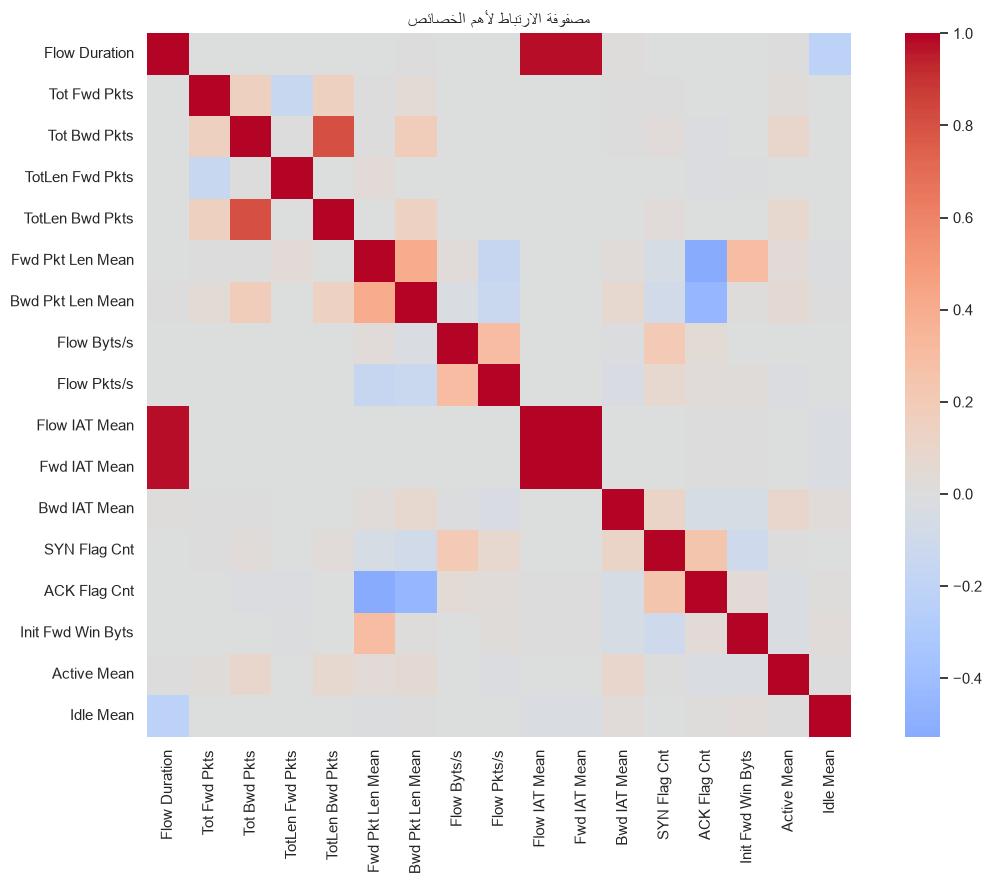

In [8]:
# قائمة بأهم الخصائص المعروفة في بيانات CICFlowMeter (إن وُجدت في الملف)
important_candidates = [
    "Flow Duration", "Tot Fwd Pkts", "Tot Bwd Pkts",
    "TotLen Fwd Pkts", "TotLen Bwd Pkts",
    "Fwd Pkt Len Mean", "Bwd Pkt Len Mean",
    "Flow Byts/s", "Flow Pkts/s",
    "Flow IAT Mean", "Fwd IAT Mean", "Bwd IAT Mean",
    "SYN Flag Cnt", "ACK Flag Cnt",
    "Init Fwd Win Byts", "Active Mean", "Idle Mean",
]

top_features = [c for c in important_candidates if c in df.columns]

# إذا الأسماء لا تطابق (اختلاف بسيط بين نسخ الـ Dataset)، نختار أعلى الخصائص تبايناً بدلاً منها
if len(top_features) < 5:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    top_features = df[numeric_cols].var().sort_values(ascending=False).head(15).index.tolist()

print(f"عدد الخصائص المستخدمة في مصفوفة الارتباط: {len(top_features)}")
print(top_features)

corr = df[top_features].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, square=True)
plt.title("مصفوفة الارتباط لأهم الخصائص")
plt.tight_layout()
plt.show()

**ماذا فعلنا ولماذا؟**
اخترنا مجموعة من أهم الخصائص العددية (وإذا لم تكن الأسماء المعروفة موجودة، اخترنا الأعمدة
الأكثر تبايناً تلقائياً)، ثم رسمنا **Heatmap** لمصفوفة الارتباط بينها. هذا يساعدنا لاحقاً
على معرفة الخصائص المرتبطة ببعضها بشدة (تكرار معلومات) والخصائص المستقلة، وهو مفيد جداً
عند اختيار الخصائص لتدريب النماذج في مرحلة قادمة.

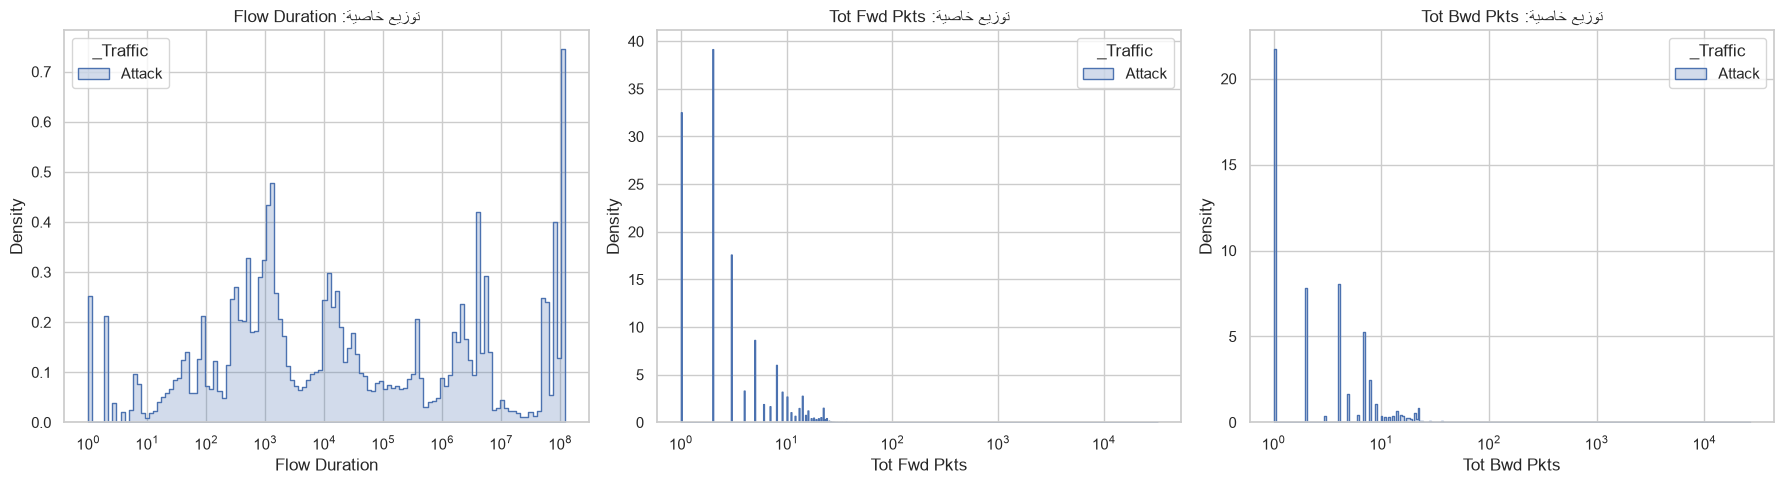

In [9]:
df["_Traffic"] = np.where(is_benign.reindex(df.index, fill_value=False), "Benign", "Attack")

dist_features = top_features[:3]

fig, axes = plt.subplots(1, len(dist_features), figsize=(6 * len(dist_features), 5))
if len(dist_features) == 1:
    axes = [axes]

for ax, feature in zip(axes, dist_features):
    sns.histplot(
        data=df, x=feature, hue="_Traffic", log_scale=(True, False),
        element="step", stat="density", common_norm=False, ax=ax,
    )
    ax.set_title(f"توزيع خاصية: {feature}")

plt.tight_layout()
plt.show()

df = df.drop(columns=["_Traffic"])

**ماذا فعلنا ولماذا؟**
رسمنا توزيع ثلاث من أهم الخصائص، مع تلوين كل رسم حسب نوع الحركة (طبيعي مقابل هجوم)
لنرى بصرياً هل هناك اختلاف واضح بين الحركتين في هذه الخصائص. استخدمنا مقياساً لوغاريتمياً
على المحور الأفقي لأن قيم هذه الخصائص غالباً متفاوتة جداً (بعضها صغير جداً وبعضها كبير جداً).

## الخلاصة

في هذا الـ Notebook قمنا بـ:
- قراءة عيّنة بيانات `CSE-CIC-IDS2018` وتنظيف أسماء الأعمدة.
- استعراض حجم البيانات وأنواعها والقيم الناقصة فيها.
- تنظيف القيم الناقصة/اللانهائية والتكرارات.
- عرض توزيع الفئات (طبيعي مقابل أنواع الهجمات) ولاحظنا عدم التوازن بين الفئات.
- رسم مصفوفة الارتباط وتوزيع أهم الخصائص.

**لم يتم تدريب أي نموذج في هذه المرحلة.** الخطوة التالية (مرحلة قادمة) هي تدريب
الخوارزميات السبع على هذه البيانات المنظّفة.